In [2]:
import torch
import torch.nn as nn 
import math
import random
import numpy as np
import cv2

In [51]:
#data = np.load(f"../part0/g2_newCamerat1.npz")
data = np.load(f"lafufu_dataset - Copy.npz")


# Training images: [100, 200, 200, 3]
images_train = data["images_train"] / 255.0

# Cameras for the training images 
# (camera-to-world transformation matrix): [100, 4, 4]
c2ws_train = data["c2ws_train"]

# Validation images: 
images_val = data["images_val"] / 255.0

# Cameras for the validation images: [10, 4, 4]
# (camera-to-world transformation matrix): [10, 200, 200, 3]
c2ws_val = data["c2ws_val"]

# Test cameras for novel-view video 6.0ing: 
# (camera-to-world transformation matrix): [60, 4, 4]
#c2ws_test = data["c2ws_test"]

# Camera focal length
#focal = data["focal"] 
K = data["K"]
#K = data["camera_matrix"]

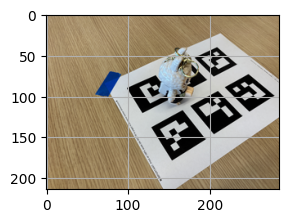

In [52]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(3,3))
plt.imshow(images_train[0])
plt.grid(True)
plt.show()

In [53]:
def transform(c2w, x_c):
    #return (c2w @ x_c.T).T
    R = c2w[:3, :3] 
    t = c2w[:3, 3]  
    x_w = (R @ x_c.T).T + t
    return x_w

def verify(x, c2w): 
    return x == transform(np.linalg.inv(c2w), transform(c2w, x))

In [54]:
c2w = np.array([
    [0, -1, 0, 1],
    [1,  0, 0, 2],
    [0,  0, 1, 3],
    [0,  0, 0, 1]
])
x_c = np.array([1, 0, 0]) 
print("Verification passed:", verify(x_c, c2w))


Verification passed: [ True  True  True]


In [55]:
def pixel_to_camera(K, uv, s):
    uv = np.atleast_2d(uv)  
    ones = np.ones((uv.shape[0], 1))
    uv_h = np.hstack([uv, ones]) 
    s_uv = s * uv_h
    return (np.linalg.inv(K) @ s_uv.T).T
    

In [57]:
def pixel_to_ray(K, c2w, uv): 
    x_c = pixel_to_camera(K, uv, 1.0)
    x_w = transform(c2w, x_c)
    r_o = c2w[:3, 3]
    r_d = x_w - r_o
    r_d_normalized = r_d / np.linalg.norm(r_d, axis=-1, keepdims=True)
    return r_o, r_d_normalized

In [58]:
class RaysData: 
    def __init__(self, images, K, c2ws):
        self.images = images
        self.K = K
        self.c2ws = c2ws
        self.H, self.W = images[0].shape[:2]  # Assume all images same size
        self.total_imgs = len(images)

        x_coords = np.arange(self.W)
        y_coords = np.arange(self.H)
        xx, yy = np.meshgrid(x_coords, y_coords, indexing='xy') 
        self.uvs = np.column_stack([xx.ravel(), yy.ravel()]) 
        self.pixels = images[0][self.uvs[:, 1], self.uvs[:, 0]] 
        self.rays_o = []
        self.rays_d = [] 
        for idx in range(self.total_imgs):
            c2w = self.c2ws[idx]
            
            uv_pixels = self.uvs + 0.5  
            r_o, r_d = pixel_to_ray(self.K, c2w, uv_pixels)
            
            self.rays_o.extend([r_o] * len(self.uvs))  
            self.rays_d.extend(r_d)  
        
        self.rays_o = np.array(self.rays_o)  
        self.rays_d = np.array(self.rays_d) 

    def sample_rays(self, N, M=3):
        img_idx = np.random.choice(self.total_imgs, size=M, replace=False)
        num_ray = N // M

        batch_colors = []
        batch_ray_o = []
        batch_ray_d = []
        
        for idx in img_idx: 
            image = self.images[idx]
            c2w = self.c2ws[idx]
            total_pixels = self.H * self.W

            batch_indices = np.random.choice(total_pixels, size=num_ray, replace=False)
            batch_y = batch_indices // self.W 
            batch_x = batch_indices % self.W 
            uv = np.column_stack([batch_x + 0.5, batch_y + 0.5])
            r_o, r_d = pixel_to_ray(self.K, c2w, uv) 
            batch_ray_o.extend([r_o] * num_ray)
            batch_ray_d.extend(r_d)
            batch_colors.extend(image[batch_y, batch_x])

        pixels = np.array(batch_colors)
        rays_o = np.array(batch_ray_o)
        rays_d = np.array(batch_ray_d)
        return rays_o, rays_d, pixels

In [59]:
def sample_along_rays_old(ray_o, ray_d, near=0.02, far=0.5, n_samples=64, random=True):
    # # Convert inputs to numpy arrays if they're tensors
    # if isinstance(ray_o, torch.Tensor):
    #     ray_o = ray_o.cpu().numpy()
    # if isinstance(ray_d, torch.Tensor):
    #     ray_d = ray_d.cpu().numpy()
    
    N = ray_o.shape[0] 
    t = np.linspace(near, far, n_samples)
    t_width = (far - near) / (n_samples - 1)
    if random: 
        t = t + np.random.rand(n_samples) * t_width
    
    points_3d = np.zeros((N, n_samples, 3))

    for ray_idx in range(N):
        for sample_idx in range(n_samples):
            points_3d[ray_idx, sample_idx] = (
                ray_o[ray_idx] + ray_d[ray_idx] * t[sample_idx]
            )   
    
    return points_3d

In [60]:
def sample_along_rays(ray_o, ray_d, near=0.02, far=0.5, n_samples=32, random=True):

    # convert to tensors if needed
    if not torch.is_tensor(ray_o):
        ray_o = torch.tensor(ray_o, dtype=torch.float32)
    if not torch.is_tensor(ray_d):
        ray_d = torch.tensor(ray_d, dtype=torch.float32)

    # If ray_o is (1,3) and ray_d is (M,3), repeat the origin
    if ray_o.dim() == 1:
        ray_o = ray_o.unsqueeze(0)
    if ray_o.shape[0] == 1 and ray_d.shape[0] > 1:
        ray_o = ray_o.expand(ray_d.shape[0], -1).contiguous()

    device = ray_o.device
    dtype = ray_o.dtype
    N = ray_d.shape[0]   # rely on directions count as canonical

    # edges and mids such that mids has length n_samples
    edges = torch.linspace(near, far, n_samples + 1, device=device, dtype=dtype)
    mids = 0.5 * (edges[:-1] + edges[1:])   # (n_samples,)
    width = (far - near) / n_samples

    if random:
        t_rand = torch.rand((N, n_samples), device=device, dtype=dtype)
        t_vals = mids.unsqueeze(0) + t_rand * width  # (N, n_samples)
    else:
        t_vals = mids.unsqueeze(0).expand(N, n_samples).to(device=device, dtype=dtype)

    points = ray_o.unsqueeze(1) + ray_d.unsqueeze(1) * t_vals.unsqueeze(-1)  # (N,n_samples,3)
    return points, t_vals



In [61]:
# H, W = images_train.shape[1:3] 
# K=np.array([[focal, 0, W/2],    
#     [0, focal, H/2],    
#     [0, 0, 1]
# ])

dataset = RaysData(images_train, K, c2ws_train)
rays_o, rays_d, pixels = dataset.sample_rays(100, M=10) # Should expect (B, 3)
points = sample_along_rays_old(rays_o, rays_d)
H, W = images_train.shape[1:3]

In [62]:
import viser, time  # pip install viser
import numpy as np

# --- You Need to Implement These ------
H, W = images_train.shape[1:3] 
# K=np.array([[focal, 0, W/2],    
#     [0, focal, H/2],    
#     [0, 0, 1]
# ])

dataset = RaysData(images_train, K, c2ws_train)
rays_o, rays_d, pixels = dataset.sample_rays(100, M=10) # Should expect (B, 3)
points = sample_along_rays_old(rays_o, rays_d)
H, W = images_train.shape[1:3]
# ---------------------------------------

server = viser.ViserServer(share=True)
# rotate = np.array([[1, 0, 0], 
#                    [0, -1, 0], 
#                    [0, 0, -1]])

for i, (image, c2w) in enumerate(zip(images_train, c2ws_train)):
    # R = c2w[:3, :3] @ rotate
    # t = c2w[:3, 3]
    # c2w_flipped = np.eye(4, dtype=np.float32)
    # c2w_flipped[:3, :3] = R
    # c2w_flipped[:3, 3] = t
    # c2w = c2w_flipped
    server.add_camera_frustum(
        f"/cameras/{i}",
        fov=2 * np.arctan2(H / 2, K[0, 0]),
        aspect=W / H,
        scale=0.01,
        wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
        position=c2w[:3, 3],
        image=image
    )
for i, (o, d) in enumerate(zip(rays_o, rays_d)):
    server.add_spline_catmull_rom(
        f"/rays/{i}", positions=np.stack((o, o + d * 6.0)),
    )
    
server.add_point_cloud(
    f"/samples",
    colors=np.zeros_like(points).reshape(-1, 3),
    points=points.reshape(-1, 3),
    point_size=0.02,
)

while True:
    time.sleep(0.1)  # Wait to allow visualization to run

╭────── viser (listening *:8099) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8099   │
│   Websocket │ ws://localhost:8099     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): https://anchor-monochrome.share.viser.studio

C:\Users\isabe\AppData\Local\Temp\ipykernel_44036\957838337.py:29: DeprecationWarning: ViserServer.add_camera_frustum has been deprecated, use ViserServer.scene.add_camera_frustum instead. Alternatively, pin to `viser<0.2.0`.
  server.add_camera_frustum(
C:\Users\isabe\AppData\Local\Temp\ipykernel_44036\957838337.py:39: DeprecationWarning: ViserServer.add_spline_catmull_rom has been deprecated, use ViserServer.scene.add_spline_catmull_rom instead. Alternatively, pin to `viser<0.2.0`.
  server.add_spline_catmull_rom(
C:\Users\isabe\AppData\Local\Temp\ipykernel_44036\957838337.py:43: DeprecationWarning: ViserServer.add_point_cloud has been deprecated, use ViserServer.scene.add_point_cloud instead. Alternatively, pin to `viser<0.2.0`.
  server.add_point_cloud(


KeyboardInterrupt: 

In [ ]:
# Visualize Cameras, Rays and Samples
import viser, time
import numpy as np

# --- You Need to Implement These ------
dataset = RaysData(images_train, K, c2ws_train)

# This will check that your uvs aren't flipped
uvs_start = 0
uvs_end = 40_000
sample_uvs = dataset.uvs[uvs_start:uvs_end] # These are integer coordinates of widths / heights (xy not yx) of all the pixels in an image
# uvs are array of xy coordinates, so we need to index into the 0th image tensor with [0, height, width], so we need to index with uv[:,1] and then uv[:,0]
assert np.all(images_train[0, sample_uvs[:,1], sample_uvs[:,0]] == dataset.pixels[uvs_start:uvs_end])

# # Uncoment this to display random rays from the first image
# indices = np.random.randint(low=0, high=40_000, size=100)

# Uncomment this to display random rays from the top left corner of the image
indices_x = np.random.randint(low=100, high=200, size=100)
indices_y = np.random.randint(low=0, high=100, size=100)
indices = indices_x + (indices_y * 200)

data = {"rays_o": dataset.rays_o[indices], "rays_d": dataset.rays_d[indices]}
points = sample_along_rays(data["rays_o"], data["rays_d"], random=True)
# ---------------------------------------

server = viser.ViserServer(share=True)
for i, (image, c2w) in enumerate(zip(images_train, c2ws_train)):
  server.add_camera_frustum(
    f"/cameras/{i}",
    fov=2 * np.arctan2(H / 2, K[0, 0]),
    aspect=W / H,
    scale=0.15,
    wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
    position=c2w[:3, 3],
    image=image
  )
for i, (o, d) in enumerate(zip(data["rays_o"], data["rays_d"])):
  positions = np.stack((o, o + d * 6.0))
  server.add_spline_catmull_rom(
      f"/rays/{i}", positions=positions,
  )
server.add_point_cloud(
    f"/samples",
    colors=np.zeros_like(points).reshape(-1, 3),
    points=points.reshape(-1, 3),
    point_size=0.03,
)

while True:
    time.sleep(0.1)  # Wait to allow visualization to run

╭────── viser (listening *:8085) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8085   │
│   Websocket │ ws://localhost:8085     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): https://teleop-faded.share.viser.studio

C:\Users\isabe\AppData\Local\Temp\ipykernel_38816\3225039921.py:29: DeprecationWarning: ViserServer.add_camera_frustum has been deprecated, use ViserServer.scene.add_camera_frustum instead. Alternatively, pin to `viser<0.2.0`.
  server.add_camera_frustum(
C:\Users\isabe\AppData\Local\Temp\ipykernel_38816\3225039921.py:40: DeprecationWarning: ViserServer.add_spline_catmull_rom has been deprecated, use ViserServer.scene.add_spline_catmull_rom instead. Alternatively, pin to `viser<0.2.0`.
  server.add_spline_catmull_rom(
C:\Users\isabe\AppData\Local\Temp\ipykernel_38816\3225039921.py:43: DeprecationWarning: ViserServer.add_point_cloud has been deprecated, use ViserServer.scene.add_point_cloud instead. Alternatively, pin to `viser<0.2.0`.
  server.add_point_cloud(


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 3 dimensions. The detected shape was (2, 100, 32) + inhomogeneous part.

In [63]:
def PE(x, L=10): 
    #single coordinate 
    encoded = [x]

    for i in range(L):
        freq = 2**i * torch.pi
        encoded.append(torch.sin(freq * x))
        encoded.append(torch.cos(freq * x))

    return torch.cat(encoded, dim=-1)


def positional_encoding_3d(coords, L = 10): 
    if isinstance(coords, np.ndarray):
        coords = torch.from_numpy(coords).float()

    x, y, z= coords[..., 0:1], coords[..., 1:2], coords[..., 2:3]
    x_encoded = PE(x, L)
    y_encoded = PE(y, L)
    z_encoded = PE(z, L)
    return torch.cat([x_encoded, y_encoded, z_encoded], dim=-1)

In [64]:
class NeRFModel(nn.Module): 
    def __init__(self, width=256, pos_L=10, dir_L=4):
        super().__init__()

        self.pos_enc_dim = 3*(2*pos_L + 1)
        self.dir_enc_dim = 3*(2*dir_L + 1)

        self.layer1 = nn.Linear(self.pos_enc_dim, width)
        self.layer2 = nn.Linear(width, width)
        self.layer3 = nn.Linear(width, width)
        self.layer4 = nn.Linear(width, width)

        self.layer5 = nn.Linear(width + self.pos_enc_dim, width)
        self.layer6 = nn.Linear(width, width)
        self.layer7 = nn.Linear(width, width)
        self.layer8 = nn.Linear(width, width)

        self.density_out = nn.Linear(width, 1)

        self.color_layer1 = nn.Linear(width, width)
        self.color_layer2 = nn.Linear(width + self.dir_enc_dim, width//2)
        self.color_out = nn.Linear(width//2, 3)

        #Activation
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, d): 
        x_encoded = positional_encoding_3d(x, L=10)
        d_encoded = positional_encoding_3d(d, L=4)

        h = self.relu(self.layer1(x_encoded))
        h = self.relu(self.layer2(h))
        h = self.relu(self.layer3(h))
        h = self.relu(self.layer4(h))
        h = torch.cat([h, x_encoded], dim=-1)
        h = self.relu(self.layer5(h))
        h = self.relu(self.layer6(h))
        h = self.relu(self.layer7(h))
        h8 = self.layer8(h)
        density = self.relu(self.density_out(h8))

        h_color = self.color_layer1(h8)
        h_color = torch.cat([h_color, d_encoded], dim=-1)
        h_color = self.relu(self.color_layer2(h_color))
        rgb = self.sigmoid(self.color_out(h_color))

        return rgb, density


In [65]:
def volrend(sigmas, rgbs, step_size):
    deltas = torch.ones_like(sigmas) * step_size
    cumulative_sigma_delta = torch.cumsum(sigmas * deltas, dim=1)
    T = torch.exp(-(cumulative_sigma_delta - sigmas * deltas))
    alphas = 1-torch.exp(-sigmas * deltas)
    weights = T * alphas
    d_colors = torch.sum(weights * rgbs, dim =1)

    return d_colors
def compute_psnr(mse_loss):
    #return 20 * torch.log10(1.0 / torch.sqrt(mse_loss))
    return 10 * torch.log10(1.0 /mse_loss)

In [66]:
import torch
torch.manual_seed(42)
sigmas = torch.rand((10, 64, 1))
rgbs = torch.rand((10, 64, 3))
step_size = (6.0 - 2.0) / 64
d_colors = volrend(sigmas, rgbs, step_size)

correct = torch.tensor([
    [0.5006, 0.3728, 0.4728],
    [0.4322, 0.3559, 0.4134],
    [0.4027, 0.4394, 0.4610],
    [0.4514, 0.3829, 0.4196],
    [0.4002, 0.4599, 0.4103],
    [0.4471, 0.4044, 0.4069],
    [0.4285, 0.4072, 0.3777],
    [0.4152, 0.4190, 0.4361],
    [0.4051, 0.3651, 0.3969],
    [0.3253, 0.3587, 0.4215]
  ])
assert torch.allclose(d_colors, correct, rtol=1e-4, atol=1e-4)

In [67]:
def create_rays_for_camera(K, c2w, H, W):
    u = np.arange(W) + 0.5
    v = np.arange(H) + 0.5
    uu, vv = np.meshgrid(u, v) 
    uv = np.column_stack([uu.ravel(), vv.ravel()]) 
    rays_o, rays_d = pixel_to_ray(K, c2w, uv)
    return torch.FloatTensor(rays_o), torch.FloatTensor(rays_d)

In [68]:
import matplotlib.pyplot as plt 

def render_validation_view(model, iteration, camera_idx=0): 
    model.eval()

    with torch.no_grad(): 
        c2w = c2ws_val[camera_idx]
        H, W = images_val.shape[1:3]

        rays_o, rays_d = create_rays_for_camera(K, c2w, H, W)

        points_3d = sample_along_rays_old(rays_o, rays_d, n_samples=32, random=False)
        points_flat = points_3d.reshape(-1,3)
        rays_d_repeated = rays_d.unsqueeze(1).repeat(1, 32, 1).reshape(-1, 3) 


        rgbs, densities = model(points_flat, rays_d_repeated)
        rgbs_reshaped = rgbs.reshape(H*W, 32, 3)
        densities_reshaped = densities.reshape(H*W, 32, 1)

        step_size= (6.0-2.0)/32
        rendered_image = volrend(densities_reshaped, rgbs_reshaped, step_size)
        rendered_image = rendered_image.reshape(H, W, 3).cpu().numpy()
        rendered_image = np.clip(rendered_image, 0, 1)
        
        plt.figure(figsize=(6, 6))  # Optional: adjust size as needed
        plt.imshow(rendered_image)
        #plt.title("Neural Field Output")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    
    model.train() 

In [69]:
# Visualization helper to call inside your training loop
# Requires: pip install viser numpy torch

import numpy as np
import time
import viser

def sample_points_along_rays_np(rays_o, rays_d, n_samples=64, near=2.0, far=6.0, perturb=True):
    """Numpy sampler: pts shape (N, n_samples, 3), z_vals (N, n_samples)"""
    N = rays_o.shape[0]
    z_lin = np.linspace(near, far, n_samples, dtype=np.float64)
    z_vals = np.tile(z_lin.reshape(1, -1), (N, 1))
    if perturb:
        t_bin = (far - near) / float(n_samples)
        z_vals = z_vals + (np.random.rand(*z_vals.shape) - 0.5) * t_bin
    pts = rays_o[:, None, :] + rays_d[:, None, :] * z_vals[..., None]
    return pts.astype(np.float32), z_vals.astype(np.float32)

def visualize_training_step(
    dataset,               # your RaysData instance (has images_train, K, c2ws_train internally or passed separately)
    K,                     # intrinsics 3x3 numpy array
    images_train,          # [N_images, H, W, 3] numpy array in 0..1
    c2ws_train,            # [N_images, 4, 4] np array
    sampled,               # the output of dataset.sample_rays(...) -> (rays_o, rays_d, pixels) or +meta
    max_rays=100,
    n_vis_samples=32,
    near=2.0,
    far=6.0,
):
    """
    Visualize one training-step worth of rays and sample points using viser.
    - sampled: either (rays_o, rays_d, pixels) OR (rays_o, rays_d, pixels, meta)
      If meta contains 'img_idxs' we use it to show only the cameras involved.
    - rays_o,rays_d are numpy arrays shape (B,3)
    - images_train pixels are expected to be float 0..1; converted to uint8 for viser thumbnails
    """
    # unpack
    if len(sampled) == 3:
        rays_o, rays_d, pixels = sampled
        meta = {}
    elif len(sampled) == 4:
        rays_o, rays_d, pixels, meta = sampled
    else:
        raise ValueError("sample_rays returned unexpected tuple length")

    rays_o = np.asarray(rays_o, dtype=np.float32)
    rays_d = np.asarray(rays_d, dtype=np.float32)

    # if meta has img_idxs use it, otherwise try to infer by comparing rays to per-image rays,
    # but simplest: attempt to read meta['img_idxs'] and fall back to all cameras
    img_idxs = meta.get("img_idxs", None)

    # pick a subset of rays to visualize (total)
    B = rays_o.shape[0]
    num_plot = min(max_rays, B)
    choose_inds = np.random.choice(B, size=num_plot, replace=False)
    vis_rays_o = rays_o[choose_inds]
    vis_rays_d = rays_d[choose_inds]

    # sample points along these rays for plotting
    pts, z_vals = sample_points_along_rays_np(vis_rays_o, vis_rays_d, n_samples=n_vis_samples, near=near, far=far, perturb=True)

    # choose unique cameras involved (if img_idxs present)
    if img_idxs is not None:
        img_idxs_arr = np.asarray(img_idxs)
        involved = np.unique(img_idxs_arr)  # cameras that contributed rays
    else:
        # fallback: show just the first camera to avoid clutter
        involved = np.array([0], dtype=int)

    # prepare server
    server = viser.ViserServer(share=True)

    H, W = images_train.shape[1], images_train.shape[2]
    f = K[0,0]

    # add only involved camera frustums + thumbnails
    for i in involved:
        img = images_train[i]
        c2w = c2ws_train[i]
        img_uint8 = np.clip((img * 255.0), 0, 255).astype(np.uint8)
        server.scene.add_camera_frustum(
            f"/cameras/{i}",
            fov=2 * np.arctan2(H / 2.0, f),
            aspect=W / float(H),
            scale=0.17,
            wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
            position=c2w[:3, 3],
            image=img_uint8,
        )

    # add splines for each selected ray
    for r_idx in range(vis_rays_o.shape[0]):
        o = vis_rays_o[r_idx]
        d = vis_rays_d[r_idx]
        # draw from origin to a point at depth (we show a little further than far to see direction)
        positions = np.stack((o, o + d * (far + 0.5))).astype(np.float32)
        server.scene.add_spline_catmull_rom(f"/rays/{r_idx}", positions=positions)

    # add point cloud of all sampled points (flatten)
    server.scene.add_point_cloud(
        "/samples",
        colors=np.zeros_like(pts).reshape(-1, 3),  # black points
        points=pts.reshape(-1, 3),
        point_size=0.02,
    )

    print("Viser server started — open URL printed by ViserServer. Showing cameras:", involved.tolist())
    # keep alive so user can open the UI
    try:
        while True:
            time.sleep(0.1)
    except KeyboardInterrupt:
        print("Visualization terminated by user.")


In [70]:
def train_nerf_3d(width=256, learning_rate=5e-4, track_psnr=True): 
    
    dataset = RaysData(images_train, K, c2ws_train)
    
    model = NeRFModel(width=width, pos_L=10, dir_L=4)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    psnr_values = []
    iteration_numbers = []

    for iteration in range(3000):

        rays_o, rays_d, pixels = dataset.sample_rays(10000, M=10)
        
        rays_o = torch.FloatTensor(rays_o)
        rays_d = torch.FloatTensor(rays_d)
        pixels = torch.FloatTensor(pixels)

        points_3d = sample_along_rays_old(rays_o, rays_d, n_samples=32, random=True)
        points_flatten = points_3d.reshape(-1,3)

        rays_d_repeated = rays_d.unsqueeze(1).repeat(1, 32, 1).reshape(-1, 3) 

        rgbs, densities = model(points_flatten, rays_d_repeated)
        rgbs_reshaped = rgbs.reshape(10000,32,3)
        densities_reshaped = densities.reshape(10000,32,1)
       
        step_size = (6.0-2.0)/32
        rendered_color = volrend(densities_reshaped, rgbs_reshaped, step_size)
        loss = loss_fn(rendered_color, pixels)

        optimizer.zero_grad()

        loss.backward()  
        optimizer.step() 
        print(f"iteration {iteration} complete")
        if iteration % 10 == 0 and track_psnr:
                psnr = compute_psnr(loss)
                psnr_values.append(psnr.item())
                iteration_numbers.append(iteration)

        if iteration % 3 == 0:
            
            psnr = compute_psnr(loss)
            print(f"Iteration {iteration}, Loss: {loss.item():.6f}, PSNR: {psnr.item():.2f} dB")

            if iteration % 500 == 0:
                print("Generating visualization...")
                render_validation_view(model,iteration)
    print("Final result visualization...")
    render_validation_view(model,iteration)
    return  model, psnr_values, iteration_numbers

In [ ]:
model, psnr_values, iterations = train_nerf_3d()

KeyboardInterrupt: 

In [71]:
import torch
checkpoint = torch.load('lafufu_default.pth', weights_only=False)

# Reconstruct the model
# You must define the same model class used during training
# For example, if it was NeRFNet(width=256), do:
model = NeRFModel(width=checkpoint['training_config']['width'])

# Load the saved weights
model.load_state_dict(checkpoint['model_state_dict'])

# Access metadata
psnr_array = checkpoint['psnr_array']
iter_numbers = checkpoint['iter_numbers']
psnr_train = checkpoint['psnr_train']
loss_list = checkpoint['loss_list']
training_config = checkpoint['training_config']
final_psnr = checkpoint['final_psnr']
final_loss = checkpoint['final_loss']


C:\Users\isabe\AppData\Local\Temp\ipykernel_25648\3068512145.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  points_3d[ray_idx, sample_idx] = (


RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 96 but got size 10656000 for tensor number 1 in the list.

In [ ]:
# Part A: visualize cameras, up to 100 rays and sample points
# Requirements: pip install viser numpy torch
import numpy as np
import torch
import viser, time

# --- CONFIG ---
MAX_RAYS_TO_PLOT = 100
N_SAMPLE_ALONG = 64      # number of points per ray to visualize
NEAR, FAR = 2.0, 6.0
# --------------------------------

# dataset arrays from your npz (expected already loaded)
# images_train: [100, H, W, 3] floats in [0,1]
# K: camera intrinsics 3x3 (single focal for lego)
# c2ws_train: [100, 4, 4]
# If your K is just focal, construct intrinsics:
H, W = images_train.shape[1], images_train.shape[2]
if isinstance(focal, np.ndarray) or focal is None:
    K = np.array([[focal, 0.0, W/2.0],
                  [0.0, focal, H/2.0],
                  [0.0, 0.0, 1.0]])
else:
    K = np.array([[focal, 0.0, W/2.0],
                  [0.0, focal, H/2.0],
                  [0.0, 0.0, 1.0]])

# ----- helper functions -----
def create_image_rays_for_all(images, Ks, c2ws):
    """Precompute rays_o, rays_d per image (numpy). Returns lists of arrays per image."""
    list_rays_o = []
    list_rays_d = []
    list_pixels = []
    for img_idx, (img, K, c2w) in enumerate(zip(images, Ks, c2ws)):
        h, w = img.shape[:2]
        # grid of pixel centers (x horizontal, y vertical)
        xs = np.arange(w, dtype=np.float32)
        ys = np.arange(h, dtype=np.float32)
        grid_x, grid_y = np.meshgrid(xs, ys)
        u = (grid_x.reshape(-1) + 0.5).astype(np.float64)
        v = (grid_y.reshape(-1) + 0.5).astype(np.float64)
        pts_h = np.stack([u, v, np.ones_like(u)], axis=-1)     # (HW,3)
        K_inv = np.linalg.inv(K)
        dirs_cam = (K_inv @ pts_h.T).T                        # (HW,3)
        # transform by rotation
        R = c2w[:3, :3]
        t = c2w[:3, 3]
        dirs_world = (R @ dirs_cam.T).T
        norms = np.linalg.norm(dirs_world, axis=-1, keepdims=True) + 1e-9
        dirs_world = dirs_world / norms
        rays_o = np.tile(t.reshape(1,3), (dirs_world.shape[0], 1))
        list_rays_o.append(rays_o.astype(np.float32))
        list_rays_d.append(dirs_world.astype(np.float32))
        list_pixels.append(np.stack([grid_x.reshape(-1), grid_y.reshape(-1)], axis=-1).astype(np.int32))
    return list_rays_o, list_rays_d, list_pixels

def sample_along_rays_np(rays_o, rays_d, n_samples=64, near=2.0, far=6.0, perturb=True):
    """Return pts (N_rays, n_samples, 3) and z_vals (N_rays, n_samples). numpy version."""
    N = rays_o.shape[0]
    z_lin = np.linspace(near, far, n_samples, dtype=np.float64)  # (n_samples,)
    z_vals = np.tile(z_lin.reshape(1, -1), (N, 1))
    if perturb:
        t_bin = (far - near) / float(n_samples)
        jitter = (np.random.rand(*z_vals.shape) - 0.5) * t_bin
        z_vals = z_vals + jitter
    pts = rays_o[:, None, :] + rays_d[:, None, :] * z_vals[..., None]
    return pts.astype(np.float32), z_vals.astype(np.float32)

# ----- prepare sampler object (simple) -----
# Pack K as list for all training images
Ks = [K for _ in range(len(images_train))]
# Precompute full-per-image rays on CPU (heavy: H*W*#images points, but OK for lego 200x200)
rays_o_list, rays_d_list, pixels_list = create_image_rays_for_all(images_train, Ks, c2ws_train)

# Build a simple sampler that picks up to MAX_RAYS_TO_PLOT rays from a random train image:
img_idx = np.random.randint(len(images_train))
rays_o_img = rays_o_list[img_idx]
rays_d_img = rays_d_list[img_idx]
pix_img = pixels_list[img_idx]

N_all = rays_o_img.shape[0]
num_to_take = min(MAX_RAYS_TO_PLOT, N_all)
inds = np.random.choice(N_all, size=num_to_take, replace=False)
rays_o = rays_o_img[inds]
rays_d = rays_d_img[inds]
pixels = pix_img[inds]   # (num_to_take, 2) with x,y

# sample points along those rays
points, z_vals = sample_along_rays_np(rays_o, rays_d, n_samples=N_SAMPLE_ALONG, near=NEAR, far=FAR, perturb=True)

# ----- Viser visualization -----
server = viser.ViserServer(share=True)

# add camera frustums & thumbnails
for i, (image, c2w) in enumerate(zip(images_train, c2ws_train)):
    server.scene.add_camera_frustum(
        f"/cameras/{i}",
        fov=2 * np.arctan2(H / 2, K[0, 0]),
        aspect=W / float(H),
        scale=0.15,
        wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
        position=c2w[:3, 3],
        image=(image * 255).astype(np.uint8)  # viser expects uint8 image
    )

# add ray splines and sample points
for i in range(rays_o.shape[0]):
    o = rays_o[i]
    d = rays_d[i]
    positions = np.stack((o, o + d * 6.0))  # endpoint at depth 6m
    server.scene.add_spline_catmull_rom(f"/rays/{i}", positions=positions)

# point cloud of samples
server.scene.add_point_cloud(
    "/samples",
    colors=np.zeros_like(points).reshape(-1, 3), # black
    points=points.reshape(-1, 3),
    point_size=0.02
)

print("Viser server started — open share link printed by ViserServer or local UI.")
# keep alive
while True:
    time.sleep(0.1)


╭────── viser (listening *:8100) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8100   │
│   Websocket │ ws://localhost:8100     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): https://nose-optic-flow.share.viser.studio

Viser server started — open share link printed by ViserServer or local UI.


(viser) Connection opened (0, 1 total), 312 persistent messages

(viser) Connection closed (0, 0 total)

KeyboardInterrupt: 

(viser) Connection closed (0, 2 total)

(viser) Connection closed (1, 1 total)

In [57]:

import torch
checkpoint = torch.load('lego_trainedwithcorrectpnsr.pth', weights_only=False)

# Reconstruct the model
# You must define the same model class used during training
# For example, if it was NeRFNet(width=256), do:
model = NeRFModel(width=checkpoint['training_config']['width'])

# Load the saved weights
model.load_state_dict(checkpoint['model_state_dict'])

# Access metadata
psnr_array = checkpoint['psnr_array']
iter_numbers = checkpoint['iter_numbers']
psnr_train = checkpoint['psnr_train']
loss_list = checkpoint['loss_list']
training_config = checkpoint['training_config']
final_psnr = checkpoint['final_psnr']
final_loss = checkpoint['final_loss']

#load model

In [ ]:
# Part B: torch volumetric rendering + validation render + spherical test video
# Requirements: torch, numpy, matplotlib, imageio
import numpy as np
import torch
import imageio
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- Utility: create rays for full camera (torch) ----
def create_rays_for_camera(K, c2w, H, W, device=torch.device('cpu')):
    """
    Returns rays_o (H*W,3) and rays_d (H*W,3) (torch tensors)
    c2w: 4x4 numpy or torch
    K: 3x3 numpy or torch (intrinsics)
    """
    if isinstance(K, np.ndarray):
        K = torch.from_numpy(K).to(device=device, dtype=torch.float32)
    if isinstance(c2w, np.ndarray):
        c2w = torch.from_numpy(c2w).to(device=device, dtype=torch.float32)

    xs = torch.arange(0, W, device=device, dtype=torch.float32)
    ys = torch.arange(0, H, device=device, dtype=torch.float32)
    grid_x, grid_y = torch.meshgrid(xs, ys, indexing='xy')  # shapes (W,H)?? using indexing='xy' -> grid_x shape (W,H) - careful
    # torch.meshgrid indexing='xy' yields grid_x shape (H,W) and grid_y (H,W) when inputs (xs, ys)
    # ensure shapes (H,W)
    grid_x = grid_x.t() if grid_x.shape != (H, W) else grid_x
    grid_y = grid_y.t() if grid_y.shape != (H, W) else grid_y

    u = (grid_x.reshape(-1) + 0.5).to(device)
    v = (grid_y.reshape(-1) + 0.5).to(device)
    ones = torch.ones_like(u)

    pts_h = torch.stack([u, v, ones], dim=-1)  # (H*W, 3)
    K_inv = torch.inverse(K)
    dirs_cam = (K_inv @ pts_h.T).T              # (H*W, 3)
    R = c2w[:3, :3]
    t = c2w[:3, 3]
    dirs_world = (R @ dirs_cam.T).T
    dirs_world = dirs_world / (dirs_world.norm(dim=-1, keepdim=True) + 1e-9)
    rays_o = t.reshape(1,3).expand(dirs_world.shape[0], 3)
    return rays_o.to(device), dirs_world.to(device)

# ---- sample along rays (torch) ----
# def sample_along_rays(rays_o, rays_d, n_samples=64, near=2.0, far=6.0, random=True, device=device):
#     """
#     rays_o, rays_d: (N,3) torch
#     returns: pts (N, n_samples, 3) and z_vals (N, n_samples)
#     if random==False deterministically use linspace centers.
#     """
#     N = rays_o.shape[0]
#     t_vals = torch.linspace(near, far, n_samples, device=device)  # (n_samples,)
#     z_vals = t_vals.unsqueeze(0).expand(N, -1).clone()           # (N, n_samples)
#     if random:
#         t_bin = (far - near) / float(n_samples)
#         jitter = (torch.rand_like(z_vals) - 0.5) * t_bin
#         z_vals = z_vals + jitter
#     pts = rays_o.unsqueeze(1) + rays_d.unsqueeze(1) * z_vals.unsqueeze(-1)
#     return pts, z_vals

# ---- volumetric rendering (torch) ----
def volrend(sigmas, rgbs, z_vals, dirs=None, white_bkgd=True):
    """
    sigmas: (N, n_samples, 1) raw densities (>=0)
    rgbs:   (N, n_samples, 3) colors in [0,1]
    z_vals: (N, n_samples) depth values
    returns: rgb_map (N,3) composite, weights (N, n_samples)
    Implementation uses delta = z_{i+1} - z_i, last delta large.
    """
    device = sigmas.device
    deltas = z_vals[:, 1:] - z_vals[:, :-1]  # (N, n_samples-1)
    delta_last = 1e10 * torch.ones_like(deltas[:, :1])
    deltas = torch.cat([deltas, delta_last], dim=1)  # (N, n_samples)
    # convert density to alpha
    alpha = 1.0 - torch.exp(-sigmas.squeeze(-1) * deltas)  # (N, n_samples)
    # weights = alpha * cumprod(1 - alpha + eps)
    eps = 1e-10
    trans = torch.cumprod(torch.cat([torch.ones((alpha.shape[0], 1), device=device), 1.0 - alpha + eps], dim=1), dim=1)[:, :-1]
    weights = alpha * trans  # (N, n_samples)
    rgb_map = torch.sum(weights.unsqueeze(-1) * rgbs, dim=1)  # (N,3)
    if white_bkgd:
        acc_map = weights.sum(dim=1, keepdim=True)  # (N,1)
        rgb_map = rgb_map + (1.0 - acc_map)  # composite onto white
    return rgb_map, weights

# ---- render a validation view (returns image) ----
def render_validation_view(model, iteration, camera_idx=0, device=device, n_samples=64, random=False):
    """
    Renders single validation image from camera index camera_idx.
    Returns rendered_image (H,W,3 float numpy clipped 0..1).
    """
    model.eval()
    with torch.no_grad():
        c2w = torch.from_numpy(c2ws_val[camera_idx]).to(device=device, dtype=torch.float32)
        H, W = images_val.shape[1], images_val.shape[2]
        rays_o, rays_d = create_rays_for_camera(K, c2w, H, W, device=device)  # (HW,3)
        pts, z_vals = sample_along_rays(rays_o, rays_d, n_samples=n_samples, near=2.0, far=6.0, random=random)
        pts_flat = pts.reshape(-1, 3)                        # (HW*n_samples, 3)
        rays_d_rep = rays_d.unsqueeze(1).expand(-1, n_samples, -1).reshape(-1, 3)  # (HW*n_samples,3)
        pts_flat = pts_flat.to(device)
        rays_d_rep = rays_d_rep.to(device)

        # model should accept (points, view_dirs) and return (rgb, sigma)
        # adapt this if your model API differs.
        model = model.to(device)

        rgbs, sigmas = model(pts_flat, rays_d_rep)   # expect tensors on device, shapes (P,3), (P,1)
        rgbs = rgbs.reshape(-1, n_samples, 3)
        sigmas = sigmas.reshape(-1, n_samples, 1)

        step_size = (6.0 - 2.0) / float(n_samples)
        rendered, _weights = volrend(sigmas, rgbs, z_vals, dirs=rays_d, white_bkgd=True)
        rendered_image = rendered.reshape(H, W, 3).cpu().numpy()
        rendered_image = np.clip(rendered_image, 0.0, 1.0)
    model.train()
    return rendered_image

# ---- PSNR helper ----
def mse_to_psnr(mse):
    return -10.0 * np.log10(mse + 1e-12)

# ---- render spherical / novel view video and save ----
def render_spherical_video(model, c2ws_test, out_path="lego_render_test.mp4", device=device, n_samples=64, fps=15):
    model.eval()
    frames = []
    H, W = images_val.shape[1], images_val.shape[2]
    for i in tqdm(range(len(c2ws_test))):
        img = render_validation_view(model, iteration=None, camera_idx=i, device=device, n_samples=n_samples, random=False)
        frames.append((img * 255).astype(np.uint8))
    # save mp4
    imageio.mimwrite(out_path, frames, fps=fps, macro_block_size=None)  # macro_block_size=None avoids rounding issues
    print("Saved video to:", out_path)
    model.train()

# ---- Example usage: generate intermediate validation images and PSNR curve ----
def produce_validation_sequence_and_plot(model, iters_to_render, device=device, n_samples=64):
    """
    iters_to_render: list of (iteration, model_state) pairs OR if you
    call this inside training loop, call render_validation_view at different iterations.
    For simplicity below we call render_validation_view with current model and iterations passed as labels.
    """
    # For demonstration, we call render for the same current model but label by iteration.
    val_psnrs = []
    imgs = []
    for iteration in iters_to_render:
        img = render_validation_view(model, iteration=iteration, camera_idx=0, device=device, n_samples=n_samples, random=False)
        imgs.append(img)
        # compute average PSNR across the 6 validation images (assumes images_val shape [10,H,W,3])
        psnrs = []
        for vidx in range(len(c2ws_val)):
            rendered = render_validation_view(model, iteration=iteration, camera_idx=vidx, device=device, n_samples=n_samples, random=False)
            gt = images_val[vidx]  # numpy float in 0..1
            mse = np.mean((rendered - gt) ** 2)
            psnrs.append(mse_to_psnr(mse))
        avg_psnr = float(np.mean(psnrs))
        val_psnrs.append(avg_psnr)
        print(f"Iteration {iteration}: avg val PSNR = {avg_psnr:.4f}")

    # Plot PSNR curve
    plt.figure(figsize=(6,3))
    plt.plot(iters_to_render, val_psnrs, marker='o')
    plt.xlabel("iteration")
    plt.ylabel("avg validation PSNR (10 images)")
    plt.grid(True)
    plt.show()

    # show images grid
    cols = min(4, len(imgs))
    rows = (len(imgs) + cols - 1) // cols
    plt.figure(figsize=(4*cols, 3*rows))
    for i, im in enumerate(imgs):
        plt.subplot(rows, cols, i+1)
        plt.imshow(im)
        plt.axis('off')
        plt.title(f"iter {iters_to_render[i]}")
    plt.show()

# ---- Example: produce a short video from c2ws_test (save mp4) ----
# Usage:
render_spherical_video(model, c2ws_test, out_path="lego_test_video.mp4", device="cuda", n_samples=64, fps=15)


Using device: cuda


  0%|          | 0/4 [00:08<?, ?it/s]


AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


(viser) Connection opened (33, 2 total), 370 persistent messages